# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [123]:
STUDENT_NAME = "Nguyễn Lê Gia Bảo"  # TODO: Họ và tên
STUDENT_ID = "2550016"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Lê Gia Bảo (2550016)


In [124]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\Bao Lap Trinh AI\EE_MLIOT\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [125]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [126]:
# TODO N1
# shifted_logits = ...
shifted_logits = logits - np.max(logits, axis = 1, keepdims = True)
# exp_logits = ...
def softmax(z):
    sum_exp = np.sum(np.exp(z))
    return np.exp(z) / sum_exp
# class_probabilities = ...
class_probabilities = np.apply_along_axis(softmax, axis = 1, arr = shifted_logits)
# predicted_classes = ...
predicted_classes = np.argmax(class_probabilities, axis = 1)
# confidence_scores = ...
confidence_scores = np.max(class_probabilities, axis = 1)


In [127]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")


N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [128]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [129]:
# TODO N2
# train_feature_mean = ...
train_feature_mean = np.mean(X_train, axis = 0)
# train_feature_std = ...
train_feature_std = np.std(X_train, axis = 0)
# X_train_scaled = ...
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
# X_val_scaled = ...
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [130]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [131]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [132]:
# TODO N3
# correct_mask = ...: mảng boolean đánh dấu xem dự đoán của mô hình có khớp không
correct_mask = predicted_classes == true_labels
# high_confidence_mask = ...:mảng boolean, bằng True nếu giá trị confidence >= 0.70
high_confidence_mask = confidence_scores >= confidence_threshold
# review_mask = ...: mảng boolean, xác định một mẫu có cần phải kiểm tra thủ công không
review_mask = (~correct_mask) | (~high_confidence_mask)
# review_indices = ...: index của các mẫu cần kiểm tra thủ công 
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [133]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [134]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255
augmented_batch = normalized_batch[:,:,::-1,:].copy() #Đảo ngược chiều của W (chiều ngang)
augmented_batch[0, 0, 0, 0] = 1

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**
1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.
2. '?'
3. Mức đánh giá rủi ro bảo hiểm

<!-- Viết câu trả lời tại đây. -->

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [135]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [136]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [137]:
# TODO D2
# df_clean = ...
df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])

missing_by_column = df_clean.isna().sum()


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

- Không nên điền tất cả các cột số bằng cùng một giá trị vì mỗi đặc trưng số có ý nghĩa vật lý và thang đo hoàn toàn khác nhau (ví dụ: price lên tới hàng chục nghìn USD, bore chỉ khoảng 3-4 inches). Việc dùng chung một giá trị sẽ làm sai lệch phân phối tự nhiên của các cột này.
- Với price, việc drop (xóa bỏ) các dòng thiếu sẽ phù hợp hơn trong bài toán EDA này. Vì price là biến mục tiêu quan trọng bậc nhất, điền giá trị giả lập (như mean/median) dễ tạo ra các mối tương quan ảo không phản ánh đúng thực tế.
- normalized_losses bị thiếu tới 41 dòng (khoảng 20% dữ liệu). Việc này làm giảm đáng kể lượng dữ liệu có thể sử dụng nếu ta drop toàn bộ, hoặc làm tăng độ nhiễu và sai số nếu ta điền giá trị thiếu bằng phương pháp không tối ưu.


## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [138]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [139]:
# TODO D3
analysis_df = df_clean.dropna(subset=AUTO_FEATURES)
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [140]:
# TODO D4
price_index = AUTO_FEATURES.index('price')
price_z = (X_auto[:, price_index] - auto_feature_mean[price_index]) / auto_feature_std[price_index]
price_outlier_mask = np.abs(price_z) > 2
price_outliers = X_auto[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [141]:
# TODO D5
engine_index = AUTO_FEATURES.index('engine_size')
price_index = AUTO_FEATURES.index('price')
engine_price_corr = np.corrcoef(X_auto[:, engine_index], X_auto[:, price_index])[0, 1]
price_by_body_style = analysis_df.groupby('body_style')['price'].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

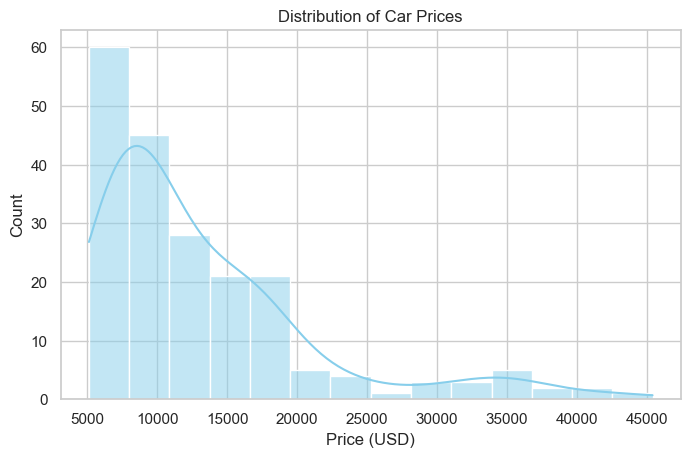

In [ ]:
# TODO M2.1: histogram/KDE của price
sns.histplot(data=df_clean, x='price', kde=True, color='skyblue')
plt.title('Distribution of Car Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.show()

**Nhận xét:** Đa số các xe tập trung ở phân khúc giá rẻ và trung cấp (từ 5,000 đến 15,000 USD). Phân phối có xu hướng lệch phải rõ rệt (right-skewed) với một số ít dòng xe cao cấp có giá rất cao trên 30,000 USD.


## M2.2 Dataset có cân bằng theo body style không?

C:\Users\Windows\AppData\Local\Temp\ipykernel_11476\139774530.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='body_style', order=df_clean['body_style'].value_counts().index, palette='Set2')


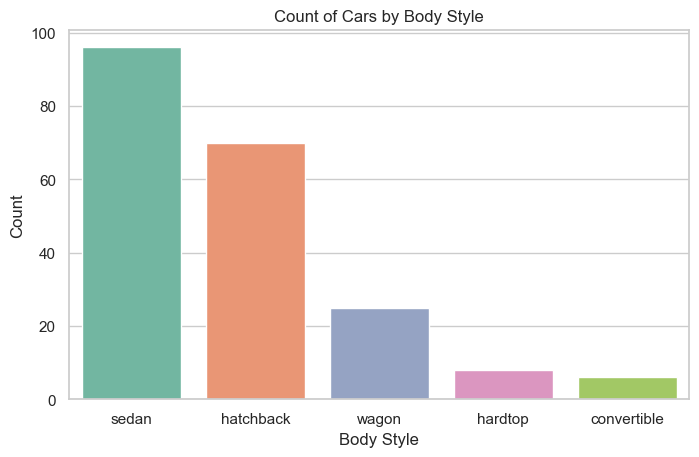

In [ ]:
# TODO M2.2: countplot của body_style
sns.countplot(data=df_clean, x='body_style', order=df_clean['body_style'].value_counts().index, palette='Set2')
plt.title('Count of Cars by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Count')
plt.show()

**Nhận xét:** Tập dữ liệu có sự mất cân bằng lớn về kiểu thân xe. Hai dòng xe Sedan và Hatchback chiếm số lượng áp đảo (hơn 160 xe), trong khi các dòng xe thể thao hoặc mui trần như Hardtop và Convertible có số lượng rất hạn chế (dưới 10 xe).


## M2.3 Price khác nhau theo body style ra sao?

C:\Users\Windows\AppData\Local\Temp\ipykernel_11476\568611925.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='body_style', y='price', palette='Pastel1')


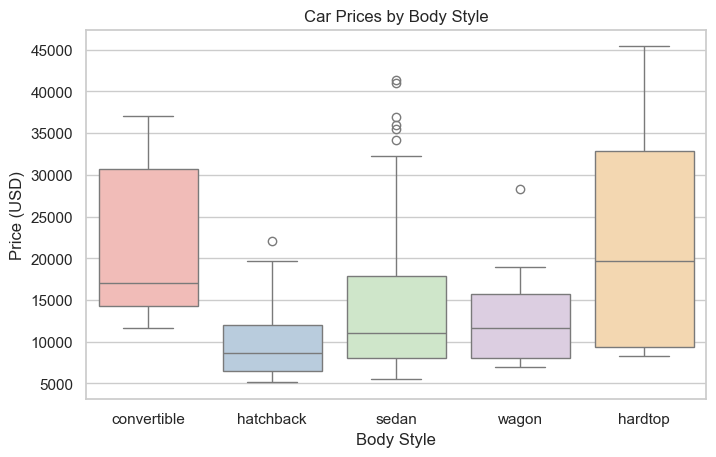

In [ ]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(data=df_clean, x='body_style', y='price', palette='Pastel1')
plt.title('Car Prices by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Price (USD)')
plt.show()

**Nhận xét:** Dòng xe Hardtop và Convertible có giá trung vị cao nhất, thể hiện phân khúc cao cấp hơn. Sedan và Hatchback tuy có giá trung vị thấp hơn nhưng có nhiều giá trị ngoại lai (outliers) có giá rất cao.


## M2.4 Engine size liên quan thế nào tới price?

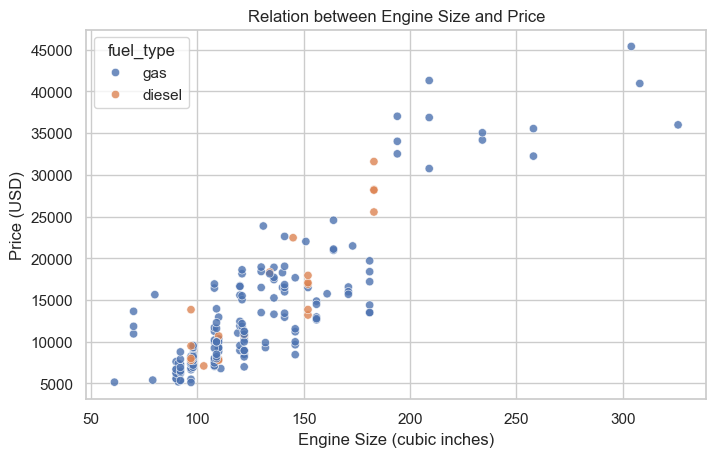

In [ ]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', alpha=0.8)
plt.title('Relation between Engine Size and Price')
plt.xlabel('Engine Size (cubic inches)')
plt.ylabel('Price (USD)')
plt.show()

**Nhận xét:** Có mối tương quan tuyến tính dương mạnh mẽ giữa dung tích động cơ và giá xe; động cơ càng lớn thì giá xe càng đắt. Phần lớn xe chạy bằng xăng (gas), trong khi xe chạy dầu (diesel) phân bố rải rác ở các mức giá khác nhau.


## M2.5 Các feature numeric tương quan ra sao?

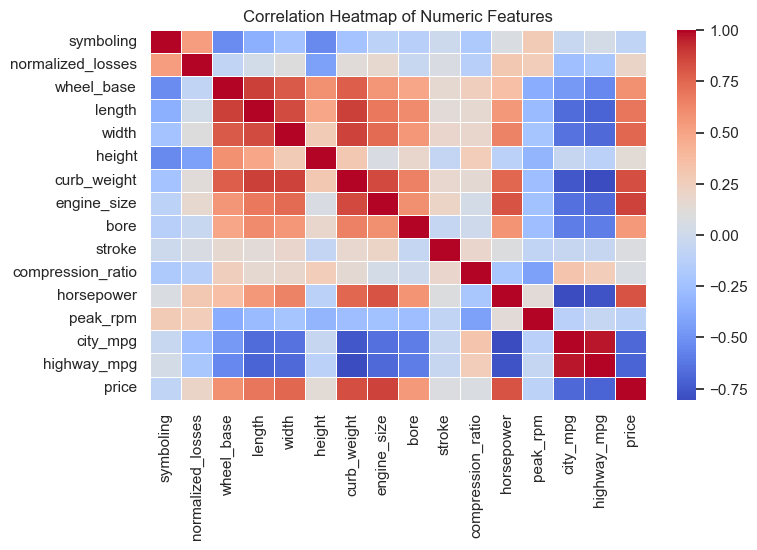

In [ ]:
# TODO M2.5: correlation heatmap
corr_matrix = df_clean[NUMERIC_COLUMNS].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

**Nhận xét:** Giá xe (price) tương quan thuận rất mạnh với curb_weight, engine_size, horsepower, và length. Ngược lại, price tương quan nghịch mạnh với city_mpg và highway_mpg, cho thấy xe đắt tiền thường tốn nhiên liệu hơn.


## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

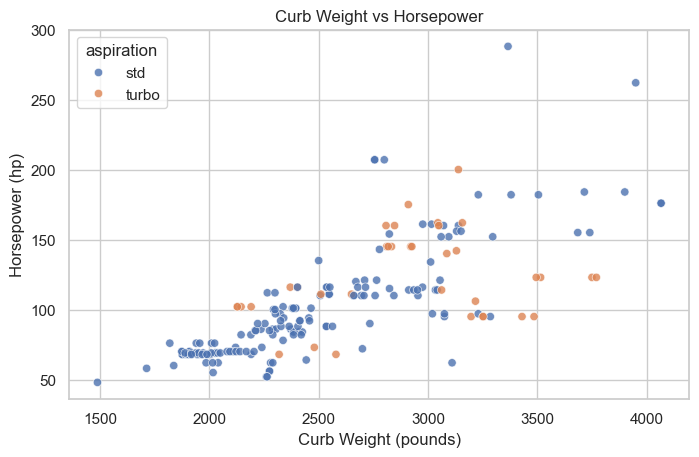

In [ ]:
# TODO M2.6: biểu đồ tự chọn
sns.scatterplot(data=df_clean, x='curb_weight', y='horsepower', hue='aspiration', alpha=0.8)
plt.title('Curb Weight vs Horsepower')
plt.xlabel('Curb Weight (pounds)')
plt.ylabel('Horsepower (hp)')
plt.show()

**Nhận xét:** Trọng lượng xe (curb_weight) và công suất động cơ (horsepower) có mối tương quan thuận mạnh mẽ. Các xe sử dụng hệ thống nạp khí tăng áp (turbo) thường đạt công suất cao hơn các xe thông thường (std) có cùng khối lượng.


# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

**1. Các phát hiện chính:**
- Dung tích động cơ (engine_size), trọng lượng xe (curb_weight), và công suất (horsepower) là những đặc trưng tương quan thuận mạnh nhất với giá xe.
- Các dòng xe mui trần (convertible) và hardtop có định giá cao cấp vượt trội so với hatchback hay sedan thông thường.
- Các đặc trưng thể hiện kích thước và sức mạnh động cơ tương quan nghịch mạnh với hiệu suất tiêu hao nhiên liệu (mpg), nghĩa là xe càng to và mạnh thì càng tốn xăng.

**2. Hạn chế của dataset:**
- Kích thước tập dữ liệu nhỏ (205 dòng) và dữ liệu lịch sử từ năm 1985, có thể không phản ánh đúng các xu hướng công nghệ động cơ lai (hybrid) hay xe điện hiện đại.
- Tỷ lệ thiếu dữ liệu ở một số cột tương đối cao, điển hình là normalized_losses thiếu tới 41 mẫu (khoảng 20%).

**3. Ví dụ Correlation vs Causation:**
- Mối tương quan thuận giữa dung tích động cơ lớn và giá xe cao. Đây là tương quan chứ không hẳn là nhân quả hoàn toàn. Việc động cơ lớn không trực tiếp làm tăng giá xe lên hàng chục nghìn USD, mà động cơ lớn thường được trang bị trên các phân khúc xe sang trọng, đi kèm nhiều tính năng cao cấp và thương hiệu đắt tiền khác.

**4. Câu hỏi nghiên cứu tiếp theo:**
- Có sự khác biệt rõ rệt về hiệu suất nhiên liệu (mpg) và công suất động cơ (horsepower) giữa các hãng sản xuất xe của các quốc gia khác nhau (Nhật, Đức, Mỹ) hay không?
